# 02. Preprocessed data overview — готовность silver → gold / CRF

Контекст пайплайна:

```text
1) regex + словари + (опц.) CRF   ← вы здесь: обучающие BIO-данные
2) ATTR typing / MM / classifiers
```

Цель ноутбука: прогнать **полный** preprocess + `WeakLabeler` (с `MODEL`), оценить качество silver-разметки и словаря `model_phrases.txt`, дать вердикт: **можно ли начинать gold**.

Связанные артефакты: `artifacts/model_phrases.txt`, `artifacts/brands.txt`, `artifacts/categories.txt`.


## 0. Setup


In [1]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().resolve()
if ROOT.name in {"preprocessing", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "preprocessing" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks, ARTIFACTS_DIR, FIGURES_DIR,
    MVIDEO_RED, DARK_SLATE, MUTED, save_stats,
)
from src.ner.labeling import (
    WeakLabeler, tokenize, lemmatize_text, bio_to_entities, entities_to_structured,
)
from src.preprocessing import QueryPreprocessor, load_phrase_list

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "preprocessing"
FIG.mkdir(parents=True, exist_ok=True)
ART = ARTIFACTS_DIR

def save_local(fig, name):
    p = FIG / name
    fig.savefig(p, dpi=160, bbox_inches="tight", facecolor="white")
    print("saved", p)
    return p

SAMPLE_N = 120_000
N_EVAL = 8_000
print("ROOT:", ROOT)


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ROOT: D:\Projects-26-06-2026\mvideo-ner-search


## 1. Полный пайплайн разметки одной строки

**Важно:** `models_path` обязателен. Без него получите ровно ваш кейс:

`asus tuf gaming a15 → BRAND + O O O`, хотя `tuf gaming a15` уже есть в словаре.


In [2]:
pp = QueryPreprocessor.from_artifacts(ART)
lab_no_model = WeakLabeler.from_files(ART / "brands.txt", ART / "categories.txt")
lab = WeakLabeler.from_files(
    ART / "brands.txt",
    ART / "categories.txt",
    models_path=ART / "model_phrases.txt",
)

def full_label(query: str, labeler=lab):
    r = pp(query)
    tags = labeler.label_query(r.text_norm)
    ents = bio_to_entities(tags, query=r.text_norm)
    return {
        "original": query,
        "text_norm": r.text_norm,
        "preprocess_model_spans": r.model_spans,
        "bio": tags,
        "entities": ents,
        "structured": entities_to_structured(ents, labeler),
        "lemma_len": len(lemmatize_text(r.text_norm)),
        "tok_len": len(tokenize(r.text_norm)),
    }

demos = [
    "asus tuf gaming a15",
    "наушники logitech g-pro x se",
    "красные холодильники samsung",
    "ноутбук 16гб",
    "пылесос dyson v15",
]
rows = []
for q in demos:
    a = full_label(q, lab_no_model)
    b = full_label(q, lab)
    rows.append({
        "query": q,
        "bio_WITHOUT_models_path": a["bio"],
        "bio_WITH_models_path": b["bio"],
        "structured": b["structured"],
        "lemma_vs_tok": f"{b['lemma_len']} vs {b['tok_len']}",
    })
pd.DataFrame(rows)


,query,bio_WITHOUT_models_path,bio_WITH_models_path,structured,lemma_vs_tok
0,asus tuf gaming a15,"[(asus, B-BRAND), (tuf, O), (gaming, O), (a15,...","[(asus, B-BRAND), (tuf, B-MODEL), (gaming, I-M...","{'brand': 'ASUS', 'category': None, 'model': '...",5 vs 4
1,наушники logitech g-pro x se,"[(наушники, B-CATEGORY), (logitech, B-BRAND), ...","[(наушники, B-CATEGORY), (logitech, B-BRAND), ...","{'brand': 'Logitech', 'category': 'наушники', ...",6 vs 6
2,красные холодильники samsung,"[(красные, B-ATTR), (холодильники, B-CATEGORY)...","[(красные, B-ATTR), (холодильники, B-CATEGORY)...","{'brand': 'Samsung', 'category': 'холодильник'...",3 vs 3
3,ноутбук 16гб,"[(ноутбук, B-CATEGORY), (16, B-ATTR), (гб, I-A...","[(ноутбук, B-CATEGORY), (16, B-ATTR), (гб, I-A...","{'brand': None, 'category': 'ноутбуки', 'model...",3 vs 3
4,пылесос dyson v15,"[(пылесос, B-CATEGORY), (dyson, B-BRAND), (v15...","[(пылесос, B-CATEGORY), (dyson, B-BRAND), (v15...","{'brand': 'Dyson', 'category': 'пылесос', 'mod...",4 vs 3


### Диагноз кейса `asus tuf gaming a15`

| Наблюдение | Вывод |
|---|---|
| В `model_phrases.txt` есть `tuf gaming a15` | словарь знает линейку |
| Без `models_path` → `tuf/gaming/a15 = O` | это не «дыра словаря», а **не подключенный** словарь |
| Natasha иногда режет `a15` → `a`+`15` | при mismatch длин включается fallback на `_normalize(token)` — матч MODEL всё равно возможен |
| Preprocess может пометить весь `asus tuf...` как MODEL | расхождение с labeler (asus = BRAND) — нормально: brand приоритетнее |

**Правильный вызов для CRF-данных:**

```python
lab = WeakLabeler.from_files(brands, categories, models_path=ART / "model_phrases.txt")
tags = lab.label_query(pp(query).text_norm)
```


## 2. Аудит `model_phrases.txt`


In [3]:
phrases = load_phrase_list(ART / "model_phrases.txt")
print("n_phrases:", len(phrases))

def phrase_flags(p: str) -> dict:
    toks = p.split()
    long_sku = any(sum(ch.isdigit() for ch in t) >= 5 for t in toks)
    has_alpha = any(any(c.isalpha() for c in t) for t in toks)
    pure_num = all(t.replace(".", "").isdigit() for t in toks)
    very_long = len(toks) >= 5
    looks_accessory = any(w in p for w in ["earpods", "cable", "чехол", "power bank", "silicone"])
    return {
        "n_tok": len(toks),
        "long_sku_digit": long_sku,
        "pure_num": pure_num,
        "very_long": very_long,
        "looks_accessory": looks_accessory,
        "ok_candidate": has_alpha and not long_sku and not pure_num and not very_long,
    }

flag_df = pd.DataFrame([{**{"phrase": p}, **phrase_flags(p)} for p in phrases])
summary = pd.DataFrame({
    "metric": [
        "total",
        "ok_candidate",
        "long_sku_digit (артикулы)",
        "very_long (>=5 tok)",
        "looks_accessory",
        "pure_num",
    ],
    "count": [
        len(flag_df),
        int(flag_df["ok_candidate"].sum()),
        int(flag_df["long_sku_digit"].sum()),
        int(flag_df["very_long"].sum()),
        int(flag_df["looks_accessory"].sum()),
        int(flag_df["pure_num"].sum()),
    ],
})
summary["share"] = summary["count"] / len(flag_df)
display(summary)

print("Примеры шума (артикулы/длинные):")
display(flag_df[flag_df["long_sku_digit"] | flag_df["very_long"]].head(12)[["phrase", "n_tok", "long_sku_digit", "very_long"]])
print("Примеры ок (tuf/g pro/...):")
display(flag_df[flag_df["phrase"].str.contains(r"^(tuf|g pro|v1[0-9]|galaxy)", regex=True)].head(12))


n_phrases: 6130


,metric,count,share
0,total,6130,1.000000
1,ok_candidate,5921,0.965905
2,long_sku_digit (артикулы),209,0.034095
3,very_long (>=5 tok),0,0.000000
4,looks_accessory,34,0.005546
5,pure_num,0,0.000000


Примеры шума (артикулы/длинные):


,phrase,n_tok,long_sku_digit,very_long
0,master stainless steel 0413330041,4,True,False
4,huawei freeclip 55037247 dove,4,True,False
5,ingenio twinkle grey 04180850,4,True,False
11,drybox amfibia family 788599,4,True,False
13,picogo digital display 10000,4,True,False
18,freeclip 55037247 dove t100,4,True,False
22,ingenio daily chef l7629453,4,True,False
36,ingenio unlimited l7639032,3,True,False
46,788598 drybox amfibia pet,4,True,False
56,matepad pro morandi 53014,4,True,False


Примеры ок (tuf/g pro/...):


C:\Users\user\AppData\Local\Temp\ipykernel_27748\3025982075.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  display(flag_df[flag_df["phrase"].str.contains(r"^(tuf|g pro|v1[0-9]|galaxy)", regex=True)].head(12))


,phrase,n_tok,long_sku_digit,pure_num,very_long,looks_accessory,ok_candidate
63,v15 detect submarine sv47,4,False,False,False,False,True
77,galaxy watch6 classic 47,4,False,False,False,False,True
78,galaxy watch8 classic 46,4,False,False,False,False,True
115,galaxy buds3 pro silver,4,False,False,False,False,True
116,galaxy watch ultra 2025,4,False,False,False,False,True
215,v15 s detect submarine,4,False,False,False,False,True
245,galaxy fit 3 graphite,4,False,False,False,False,True
246,galaxy fit3 silver sm,4,False,False,False,False,True
247,galaxy watch ultra 47,4,False,False,False,False,True
248,galaxy watch8 classic,3,False,False,False,False,True


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\preprocessing\10_model_phrases_quality.png


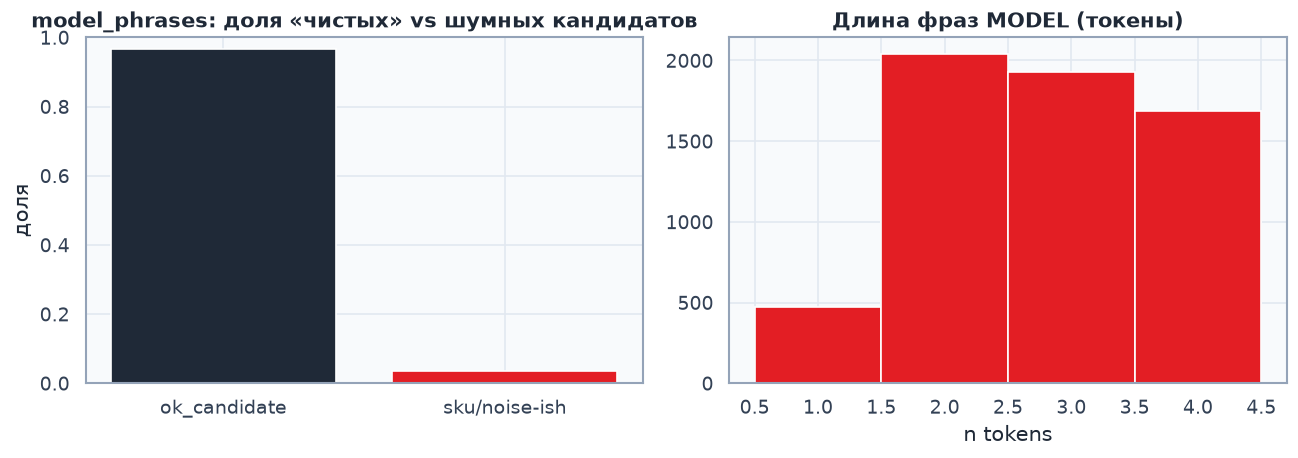

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    ["ok_candidate", "sku/noise-ish"],
    [flag_df["ok_candidate"].mean(), 1 - flag_df["ok_candidate"].mean()],
    color=[DARK_SLATE, MVIDEO_RED],
)
axes[0].set_ylim(0, 1)
axes[0].set_title("model_phrases: доля «чистых» vs шумных кандидатов")
axes[0].set_ylabel("доля")

axes[1].hist(flag_df["n_tok"], bins=range(1, int(flag_df["n_tok"].max()) + 2),
             color=MVIDEO_RED, edgecolor="white", align="left")
axes[1].set_title("Длина фраз MODEL (токены)")
axes[1].set_xlabel("n tokens")
fig.tight_layout()
save_local(fig, "10_model_phrases_quality.png")
plt.show()


## 3. Покрытие silver BIO на семпле запросов

Сравниваем labeler **без** / **с** `models_path` после preprocess.


In [5]:
clicks = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
uq = clicks["query_text"].astype(str).str.strip()
uq = uq[uq.str.len() >= 2].drop_duplicates()
sample_q = uq.sample(n=min(N_EVAL, len(uq)), random_state=42).tolist()

def eval_labeler(labeler):
    type_counts = Counter()
    n_empty = 0
    n_lemma_mismatch = 0
    n_has_model = 0
    n_brand_o_tail = 0  # BRAND + латинский хвост из O
    hard = []
    for q in sample_q:
        r = pp(q)
        qn = r.text_norm
        toks = tokenize(qn)
        lems = lemmatize_text(qn)
        if len(toks) != len(lems):
            n_lemma_mismatch += 1
        tags = labeler.label_query(qn)
        bs = [t[2:] for _, t in tags if t.startswith("B-")]
        type_counts.update(bs)
        if not bs:
            n_empty += 1
        if "MODEL" in bs:
            n_has_model += 1
        # brand + O latin tail
        bidx = [i for i, (_, t) in enumerate(tags) if t.endswith("BRAND")]
        if bidx:
            last = max(bidx)
            tail = tags[last + 1:]
            if tail and all(t == "O" for _, t in tail):
                tt = [tok for tok, _ in tail]
                if np.mean([x.isascii() and x.isalnum() for x in tt]) >= 0.6:
                    n_brand_o_tail += 1
                    if len(hard) < 15 and any(c.isalpha() for c in "".join(tt)):
                        hard.append({"query": qn, "o_tail": " ".join(tt[:6]), "bio": tags})
    n = len(sample_q)
    return {
        "n": n,
        "empty_share": n_empty / n,
        "lemma_mismatch_share": n_lemma_mismatch / n,
        "has_MODEL_share": n_has_model / n,
        "brand_latin_O_tail_share": n_brand_o_tail / n,
        "type_counts": dict(type_counts),
        "hard_tails": hard,
    }

stats_off = eval_labeler(lab_no_model)
stats_on = eval_labeler(lab)

cmp = pd.DataFrame([
    {"setting": "without models_path", **{k: stats_off[k] for k in ["empty_share", "has_MODEL_share", "brand_latin_O_tail_share", "lemma_mismatch_share"]}},
    {"setting": "with models_path", **{k: stats_on[k] for k in ["empty_share", "has_MODEL_share", "brand_latin_O_tail_share", "lemma_mismatch_share"]}},
])
display(cmp)
print("entity B-* counts WITH models:", stats_on["type_counts"])
print("Оставшиеся hard O-хвосты (кандидаты в gold MODEL):")
display(pd.DataFrame(stats_on["hard_tails"])[["query", "o_tail"]].head(12) if stats_on["hard_tails"] else pd.DataFrame({"msg": ["мало"]}))


,setting,empty_share,has_MODEL_share,brand_latin_O_tail_share,lemma_mismatch_share
0,without models_path,0.19625,0.00000,0.199750,0.18225
1,with models_path,0.18325,0.15025,0.123375,0.18225


entity B-* counts WITH models: {'CATEGORY': 5302, 'BRAND': 4040, 'MODEL': 1306, 'ATTR': 808}
Оставшиеся hard O-хвосты (кандидаты в gold MODEL):


,query,o_tail
0,asus rog ally,rog ally
1,сушильная машина hisense dhqe800bw2,dhqe800bw2
2,arctic liquid freezer iii pro,liquid freezer iii pro
3,чехол iphone 17 promax,17 promax
4,realme c 75,c 75
5,ноутбук lenovo legion,legion
6,bosch pie631hb1 e,pie631hb1 e
7,телевизор hisense 55e8 s,55e8 s
8,мфу лазерное brother dcp l5510 dn,dcp l5510 dn
9,смартфон samsung galaxy а 56 8 256,а 56 8 256


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\preprocessing\11_silver_coverage_with_without_model.png


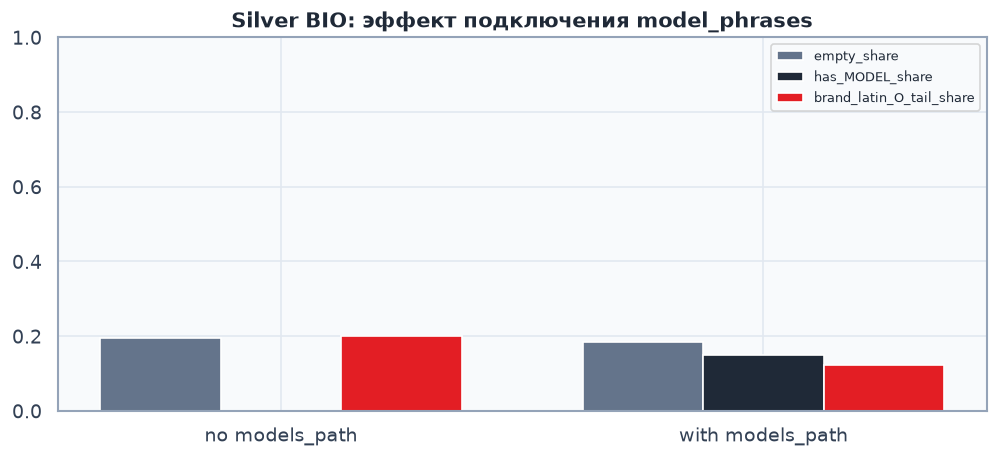

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(2)
w = 0.25
metrics = ["empty_share", "has_MODEL_share", "brand_latin_O_tail_share"]
colors = [MUTED, DARK_SLATE, MVIDEO_RED]
for i, m in enumerate(metrics):
    ax.bar(x + (i - 1) * w, [stats_off[m], stats_on[m]], w, label=m, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(["no models_path", "with models_path"])
ax.set_ylim(0, 1)
ax.set_title("Silver BIO: эффект подключения model_phrases")
ax.legend(fontsize=8)
fig.tight_layout()
save_local(fig, "11_silver_coverage_with_without_model.png")
plt.show()


## 4. Вердикт для CRF / gold

### Можно ли начинать ручную разметку (gold)?

**Да — можно и нужно начинать**, но не как «замену» словаря, а как:

1. **eval / test** (честные метрики CRF, не silver-vs-silver);
2. **дообучение /纠偏** на hard tails, которых нет в `model_phrases` или которые словарь шумит.

Рекомендуемый объём первой волны: **300–500** запросов, стратификация:
- с BRAND + латинским хвостом;
- с ATTR (память/диагональ);
- «пустые» / только CATEGORY;
- спорные цвета / Title Case.

Формат (JSONL):

```json
{"query": "asus tuf gaming a15", "entities": [
  {"text": "asus", "label": "BRAND"},
  {"text": "tuf gaming a15", "label": "MODEL"}
]}
```

Путь: `artifacts/gold/query_entities.jsonl`.

### Подводные камни обучающих данных (stage-1 NER)

| Риск | Почему важно | Что сделать |
|---|---|---|
| Silver без `models_path` | CRF не видит класс MODEL | всегда передавать `model_phrases.txt` |
| Шум в `model_phrases` (~артикулы, 5+ токенов, аксессуары) | ложные B-MODEL → CRF учит мусор | пересобрать с `min_count>=6`, выкинуть long digit SKU |
| Natasha режет `a15`→`a`+`15` | mismatch токенов; иногда ломает матч | fallback уже есть; в gold размечать по **вашей** токенизации |
| Brand aliases (`galaxy` = BRAND) | часть «модели» уезжает в BRAND | в gold явно решить политику: `samsung` BRAND, `galaxy s24` MODEL |
| Клики ≠ золото intent | majority brand шумный | gold только по тексту запроса, не по клику |
| Train/test leak | одни и те же запросы | split по `query`, не по кликам |

### Трешхолды (практика)

| Параметр | Рекомендация сейчас |
|---|---|
| `min_count` для майнинга MODEL | **6–8** (словарь 6k слишком жирный — много шума в head) |
| однотокен MODEL | только `v15`/`g305`/`m2`-like (буква+цифра) |
| max tokens | **4** |
| отсев | digit-run ≥5 в токене (артикул), accessory keywords |
| доля gold от silver | не гнаться за 100% coverage словаря — gold на хвост |

### Итог одной фразой

Предобработка и схема BIO **готовы как bootstrap** для CRF; словарь MODEL работает, если его **подключать**.  
К gold можно приступать **сейчас**, параллельно почистив `model_phrases` от артикулов — иначе CRF получит шумные silver-лейблы на MODEL.


In [7]:
# Рекомендуемый «чистый» срез словаря (не перезаписываем файл без явного флага)
CLEAN = flag_df[
    flag_df["ok_candidate"]
    & ~flag_df["looks_accessory"]
].copy()
print(f"clean subset: {len(CLEAN)} / {len(flag_df)} ({len(CLEAN)/len(flag_df):.1%})")

# Показать, что tuf gaming a15 сохранится
must = ["tuf gaming a15", "g pro x se", "v15"]
for m in must:
    print(m, "in clean:", m in set(CLEAN["phrase"]) or m in load_phrase_list(ART/"model_phrases.txt"))

REWRITE = False  # поставьте True, чтобы перезаписать artifacts/model_phrases.txt очищенным срезом + MODEL_SEEDS
if REWRITE:
    from src.preprocessing.pipeline import MODEL_SEEDS
    from src.preprocessing import save_phrase_list
    keep = set(CLEAN["phrase"]) | set(MODEL_SEEDS)
    save_phrase_list(keep, ART / "model_phrases.txt")
    print("rewrote model_phrases.txt", len(keep))
else:
    print("REWRITE=False — словарь на диске не трогаем; для очистки переключите флаг.")

out = {
    "n_model_phrases": int(len(phrases)),
    "n_ok_candidate": int(flag_df["ok_candidate"].sum()),
    "ok_share": float(flag_df["ok_candidate"].mean()),
    "silver_with_model": {k: stats_on[k] for k in ["empty_share", "has_MODEL_share", "brand_latin_O_tail_share", "lemma_mismatch_share"]},
    "silver_without_model": {k: stats_off[k] for k in ["empty_share", "has_MODEL_share", "brand_latin_O_tail_share", "lemma_mismatch_share"]},
    "verdict": "start_gold_now_parallel_to_dict_cleanup",
    "asus_tuf_note": "needs models_path; phrase exists in model_phrases.txt",
}
save_stats(out, "preprocessed_data_overview.json")
pd.DataFrame([(k, str(v)) for k, v in out.items()], columns=["key", "value"])


clean subset: 5894 / 6130 (96.2%)
tuf gaming a15 in clean: True
g pro x se in clean: True
v15 in clean: True
REWRITE=False — словарь на диске не трогаем; для очистки переключите флаг.
Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\preprocessed_data_overview.json


,key,value
0,n_model_phrases,6130
1,n_ok_candidate,5921
2,ok_share,0.965905383360522
3,silver_with_model,"{'empty_share': 0.18325, 'has_MODEL_share': 0...."
4,silver_without_model,"{'empty_share': 0.19625, 'has_MODEL_share': 0...."
5,verdict,start_gold_now_parallel_to_dict_cleanup
6,asus_tuf_note,needs models_path; phrase exists in model_phra...


*мысои и руками*

Тестируем разные кейсы

In [ ]:
labels = [
    "айфон 15 small",
    "восемь телефонов 12 про макс",
    "а йфон"
]

from pprint import pprint
for label in labels:
    pprint(full_label(label, lab))
    print("-="*10)

{'bio': [('айфон', 'B-BRAND'), ('15', 'O'), ('small', 'O')],
 'entities': [{'label': 'BRAND', 'span': [0, 5], 'text': 'айфон'}],
 'lemma_len': 3,
 'original': 'айфон 15 small',
 'preprocess_model_spans': [],
 'structured': {'attributes': {},
                'brand': 'Apple',
                'category': None,
                'model': None},
 'text_norm': 'айфон 15 small',
 'tok_len': 3}
-=-=-=-=-=-=-=-=-=-=
{'bio': [('восемь', 'O'),
         ('телефонов', 'B-CATEGORY'),
         ('12', 'O'),
         ('про', 'O'),
         ('макс', 'O')],
 'entities': [{'label': 'CATEGORY', 'span': [7, 16], 'text': 'телефонов'}],
 'lemma_len': 5,
 'original': 'восемь телефонов 12 про макс',
 'preprocess_model_spans': [],
 'structured': {'attributes': {},
                'brand': None,
                'category': 'телефон',
                'model': None},
 'text_norm': 'восемь телефонов 12 про макс',
 'tok_len': 5}
-=-=-=-=-=-=-=-=-=-=
